In [2]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

conn = duckdb.connect('dev.duckdb')

## Q1. Emissions Trends

   company_id company_name  year  total(tCO2e)
0       CO-01    Company A  2019  6.739907e+05
1       CO-01    Company A  2020  4.357244e+05
2       CO-01    Company A  2021  7.924799e+05
3       CO-01    Company A  2022  7.851695e+05
4       CO-01    Company A  2023  6.145637e+05
5       CO-01    Company A  2024  7.803075e+05
6       CO-02    Company B  2019  1.282394e+06
7       CO-02    Company B  2020  1.280936e+06
8       CO-02    Company B  2021  1.475940e+06
9       CO-02    Company B  2022  1.462183e+06
10      CO-02    Company B  2023  1.361544e+06
11      CO-02    Company B  2024  1.447391e+06
12      CO-03    Company C  2019  8.051683e+05
13      CO-03    Company C  2020  6.557562e+05
14      CO-03    Company C  2021  7.601466e+05
15      CO-03    Company C  2022  6.178544e+05
16      CO-03    Company C  2023  7.371089e+05
17      CO-03    Company C  2024  6.359117e+05
18      CO-04    Company D  2019  8.027110e+04
19      CO-04    Company D  2020  7.941570e+04
20      CO-04

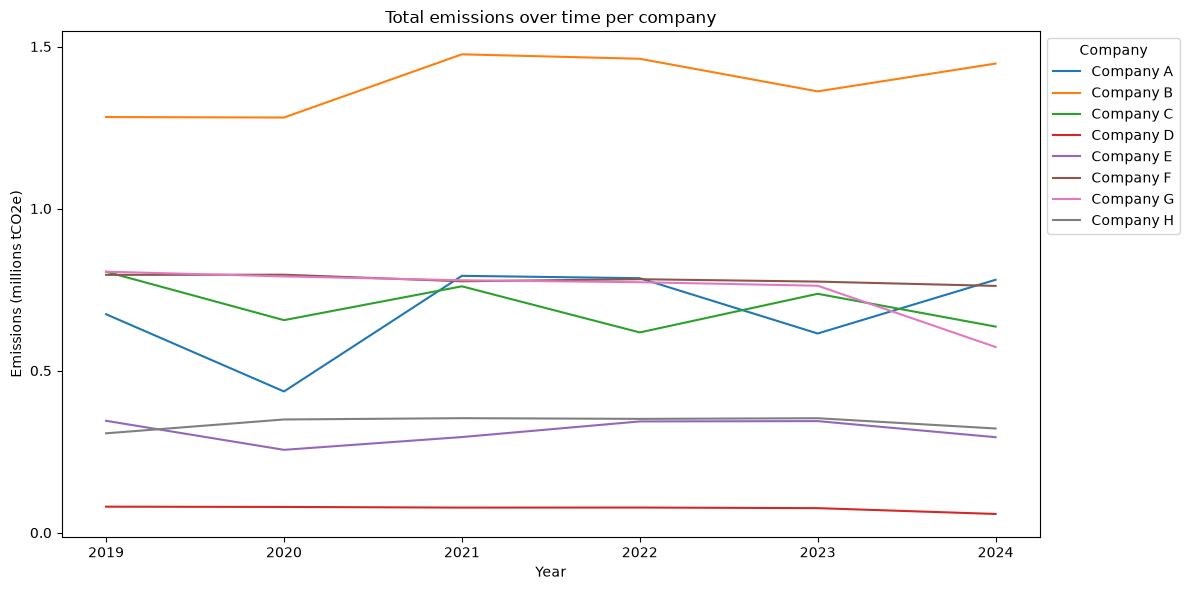

  company_name  total_baseline  total_latest  absolute_change  pct_change
6    Company G    8.052665e+05  5.728672e+05   -232399.293945      -28.86
3    Company D    8.027110e+04  5.777580e+04    -22495.299561      -28.02
2    Company C    8.051683e+05  6.359117e+05   -169256.593750      -21.02
4    Company E    3.452295e+05  2.946295e+05    -50600.004395      -14.66
5    Company F    7.955353e+05  7.613988e+05    -34136.507812       -4.29
7    Company H    3.065864e+05  3.214659e+05     14879.498047        4.85
1    Company B    1.282394e+06  1.447391e+06    164996.251953       12.87
0    Company A    6.739907e+05  7.803075e+05    106316.798828       15.77


In [3]:
q1 = conn.execute("""
    SELECT company_id, company_name, year, SUM(emissions_tco2e) as 'total(tCO2e)',
    FROM fct_emissions
	WHERE is_negative_emission = FALSE
    GROUP BY company_id, company_name, year
    ORDER BY company_id, year
""").df()
print(q1)

fig, ax = plt.subplots(figsize=(12, 6))
q1.pivot(index='year', columns='company_name', values='total(tCO2e)').plot(ax=ax)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1_000_000:.1f}'))
ax.yaxis.set_major_locator(ticker.MultipleLocator(500_000))
ax.set_title('Total emissions over time per company')
ax.set_xlabel('Year')
ax.set_ylabel('Emissions (millions tCO2e)')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), title='Company')
plt.tight_layout()
plt.show()

baseline = q1[q1['year'] == 2019][['company_name', 'total(tCO2e)']].rename(columns={'total(tCO2e)': 'total_baseline'})
latest = q1[q1['year'] == 2024][['company_name', 'total(tCO2e)']].rename(columns={'total(tCO2e)': 'total_latest'})
comparison = baseline.merge(latest, on='company_name')
comparison['absolute_change'] = comparison['total_latest'] - comparison['total_baseline']
comparison['pct_change'] = (comparison['absolute_change'] / comparison['total_baseline'] * 100).round(2)
comparison = comparison.sort_values('pct_change')
print(comparison[['company_name', 'total_baseline', 'total_latest', 'absolute_change', 'pct_change']])

- **5 out of 8 companies are reducing their emissions between 2019 and 2024.**
- **Company G** is the strongest performer with a -28.9% total reduction. It's a solid reduction path toward the SBTi target of -42% by 2030, though further effort is needed.
- **Company C** and **Company D** are also on a solid reduction path (-21.0% and -28.0% respectively).
- **Company F** and **Company E** are reducing but modestly (-4.3% and -14.7%). They might struggle to meet their targets by 2030.
- **Company H** shows a marginal increase (+4.9%). Emissions curve is essentially flat but it is moving in the wrong direction.
- **Company A** (+15.8%) and **Company B** (+12.9%) are the most concerning. Both are significantly increasing their emissions from baseline.
- **Company B** remains by far the largest emitter in absolute terms (~1.4M tCO2e in 2024) and is still growing. It's the highest-risk company in the dataset.
- **Company A** will be selected for the Q3 deep dive as it shows the highest percentage increase (+15.8%) among companies with notable variability over time, making it the most analytically interesting candidate to decompose emission drivers.

**Note:** 3 rows with negative emissions were excluded from this analysis as they could not be validated without business context. This notably affected Company G, whose reduction rate changed from -51.6% to -28.9% after exclusion.

## Q2. Major Emission Drivers

In [4]:
q2_total = conn.execute("""
    SELECT 
        category,
        SUM(emissions_tco2e) as total_emissions,
        ROUND(SUM(emissions_tco2e) * 100.0 / SUM(SUM(emissions_tco2e)) OVER (), 2) as pct_of_total
    FROM fct_emissions
	WHERE is_negative_emission = FALSE
    GROUP BY category
    ORDER BY total_emissions DESC
""").df()

print(q2_total)

                     category  total_emissions  pct_of_total
0          upstream transport     6.181053e+06         20.51
1                       waste     5.729608e+06         19.01
2  purchased goods & services     5.418942e+06         17.98
3             business travel     4.789770e+06         15.90
4       purchased electricity     2.089777e+06          6.94
5      purchased heat & steam     1.974184e+06          6.55
6          fugitive emissions     1.198293e+06          3.98
7           process emissions     9.475028e+05          3.14
8           mobile combustion     9.232896e+05          3.06
9       stationary combustion     8.810535e+05          2.92


In [5]:
q2_trend = conn.execute("""
    WITH by_year AS (
        SELECT
            category,
            year,
            SUM(emissions_tco2e) as total
        FROM fct_emissions
        GROUP BY category, year
    ),
    baseline AS (
        SELECT category, total as baseline_total
        FROM by_year 
		WHERE year = 2019
    ),
    latest AS (
        SELECT category, total as latest_total
        FROM by_year 
		WHERE year = 2024
    )
    SELECT
        b.category,
        b.baseline_total,
        l.latest_total,
        l.latest_total - b.baseline_total as absolute_change,
        ROUND((l.latest_total - b.baseline_total) / b.baseline_total * 100, 2) as pct_change
    FROM baseline b
    JOIN latest l ON b.category = l.category
    ORDER BY pct_change
""").df()

print(q2_trend)

                     category  baseline_total  latest_total  absolute_change  \
0          upstream transport    1.017642e+06  6.399613e+05   -377680.798828   
1       purchased electricity    4.312882e+05  2.988340e+05   -132454.193359   
2                       waste    1.120132e+06  8.333861e+05   -286745.993164   
3       stationary combustion    1.728574e+05  1.402217e+05    -32635.701050   
4           mobile combustion    1.667089e+05  1.410991e+05    -25609.803467   
5      purchased heat & steam    3.523044e+05  3.063601e+05    -45944.304688   
6           process emissions    1.659933e+05  1.494163e+05    -16577.002441   
7          fugitive emissions    1.988812e+05  2.006863e+05      1805.106323   
8  purchased goods & services    8.256194e+05  8.644217e+05     38802.318359   
9             business travel    6.430151e+05  1.113949e+06    470933.924805   

   pct_change  
0      -37.11  
1      -30.71  
2      -25.60  
3      -18.88  
4      -15.36  
5      -13.04  
6      

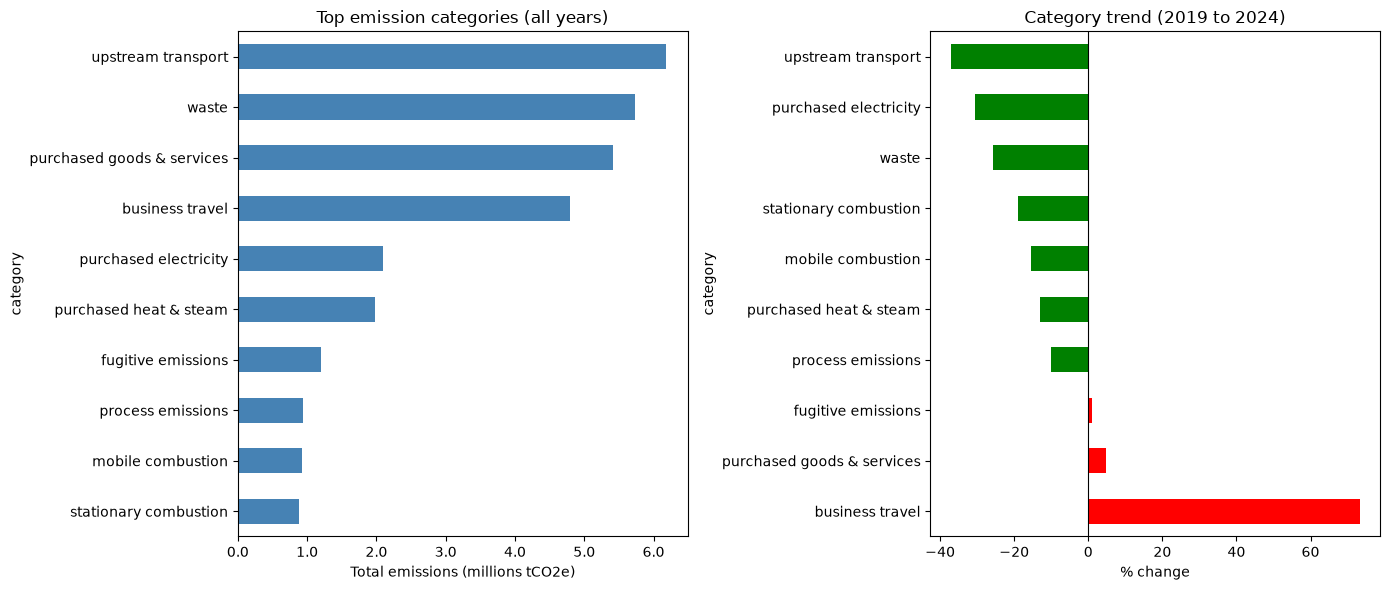

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

q2_total.head(12).plot(
    kind='barh', x='category', y='total_emissions',
    ax=axes[0], color='steelblue', legend=False
)
axes[0].set_title('Top emission categories (all years)')
axes[0].xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{x/1_000_000:.1f}')
)
axes[0].set_xlabel('Total emissions (millions tCO2e)')
axes[0].invert_yaxis()

colors = ['green' if x < 0 else 'red' for x in q2_trend['pct_change']]
q2_trend.plot(
    kind='barh', x='category', y='pct_change',
    ax=axes[1], color=colors, legend=False
)
axes[1].set_title('Category trend (2019 to 2024)')
axes[1].set_xlabel('% change')
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### Top contributing categories (all years combined)

The four largest emission categories account for over 74% of total emissions:

- **Upstream transport** is the single largest driver (20.5% of total, 6.2M tCO2e)
- **Waste** (19.0%) and **Purchased goods & services** (18.0%) follow closely
- **Business travel** (15.9%) is the fourth largest despite being a single activity

All four are **Scope 3 categories**, that is indirect emissions outside of direct operations. Together they represent ~74% of total emissions, confirming that Scope 3 dominates these companies' carbon footprints.
Scope 1 and 2 categories (stationary combustion, mobile combustion, purchased electricity, purchased heat & steam) collectively account for only ~19% of total emissions.

### Category trends (2019 to 2024)

**Decreasing categories (8 out of 10):**
- **Upstream transport** shows the largest absolute reduction (-377k tCO2e, -37.1%) and therefore the most significant progress in the dataset
- **Purchased electricity** (-30.7%) and **Waste** (-25.6%) also show strong reductions.
- All Scope 1 categories (stationary combustion, mobile combustion, process emissions) are declining, suggesting progress on direct operational efficiency.
- **Fugitive emissions** are essentially flat (+0.9%). There is no meaningful change

**Increasing categories (2 out of 10):**
- **Business travel** is by far the fastest growing category (+73.2%, +471k tCO2e). This is particularly concerning given it is already the fourth largest emitter in absolute terms
- **Purchased goods & services** is also growing (+4.7%). Given it is already the third largest contributor at 18% of total emissions, it should be looked out for.

### Notable observations

- Companies appear to be making stronger progress on categories they directly control (energy, combustion) while struggling with harder-to-abate Scope 3 drivers
- The two growing categories are both **Scope 3**, which are the hardest to control as they depend on supplier behaviour and employee choices rather than direct operations.
- The strong reduction in upstream transport (-37.1%) despite it being the largest emitter suggests targeted supply chain efforts. However **Business travel growth (+471k tCO2e) almost entirely offsets upstream transport reduction (-378k tCO2e)**, inducing a net near-zero progress on the two largest Scope 3 drivers.

## Q3. Company A Deep Dive

In [7]:
q3 = conn.execute("""
    SELECT
        year,
        scope,
        category,
        SUM(emissions_tco2e) as total_emissions
    FROM fct_emissions
    WHERE company_name = 'Company A'
		AND is_negative_emission = FALSE
    GROUP BY year, scope, category
    ORDER BY year, total_emissions DESC
""").df()

print(q3)

    year  scope                    category  total_emissions
0   2019      3          upstream transport    156969.203125
1   2019      3             business travel    121535.601562
2   2019      3                       waste    118065.398438
3   2019      2      purchased heat & steam     74124.398438
4   2019      2       purchased electricity     68145.601562
5   2019      1          fugitive emissions     42814.699219
6   2019      1       stationary combustion     40637.601562
7   2019      1           mobile combustion     29718.400391
8   2019      1           process emissions     21979.800781
9   2020      3          upstream transport    167909.906250
10  2020      2      purchased heat & steam     72656.296875
11  2020      2       purchased electricity     63690.500000
12  2020      1          fugitive emissions     42589.699219
13  2020      1       stationary combustion     38257.800781
14  2020      1           mobile combustion     29433.699219
15  2020      1         

In [8]:
q3_drivers = conn.execute("""
    WITH baseline AS (
        SELECT scope, category, SUM(emissions_tco2e) as baseline_total
        FROM fct_emissions
        WHERE company_name = 'Company A' AND year = 2019
        GROUP BY scope, category
    ),
    latest AS (
        SELECT scope, category, SUM(emissions_tco2e) as latest_total
        FROM fct_emissions
        WHERE company_name = 'Company A' AND year = 2024
        GROUP BY scope, category
    )
    SELECT
        b.scope,
        b.category,
        b.baseline_total,
        l.latest_total,
        l.latest_total - b.baseline_total as absolute_change,
        ROUND((l.latest_total - b.baseline_total) / b.baseline_total * 100, 2) as pct_change
    FROM baseline b
    JOIN latest l ON b.scope = l.scope AND b.category = l.category
    ORDER BY absolute_change DESC
""").df()
print(q3_drivers)

print("\n")
sbti = conn.execute("""
    SELECT DISTINCT
        company_name,
        target_id,
        sbti_validated,
        reduction_pct,
        target_year
    FROM fct_company_target_status
    WHERE company_name = 'Company A'
""").df()
print(sbti)

print("\n")
pgs = pd.read_csv('seeds/emissions.csv')
mask = (pgs['company_id'] == 'CO-01') & \
       (pgs['category'].str.lower().isin(['purchased goods & services']))
print(pgs[mask][['year', 'category', 'emissions_tco2e']].sort_values('year'))

print("\n")
bt = pd.read_csv('seeds/emissions.csv')
mask = (bt['company_id'] == 'CO-01') & \
       (bt['category'].str.lower().isin(['business travel', 'travel']))
print(bt[mask][['year', 'category', 'emissions_tco2e']].sort_values('year'))

   scope                category  baseline_total   latest_total  \
0      3         business travel   121535.601562  164375.406250   
1      3      upstream transport   156969.203125  181640.593750   
2      1      fugitive emissions    42814.699219   41033.601562   
3      1       process emissions    21979.800781   19070.500000   
4      1       mobile combustion    29718.400391   25389.199219   
5      2  purchased heat & steam    74124.398438   65533.101562   
6      1   stationary combustion    40637.601562   31842.000000   
7      2   purchased electricity    68145.601562   50126.000000   
8      3                   waste   118065.398438   86096.500000   

   absolute_change  pct_change  
0     42839.804688       35.25  
1     24671.390625       15.72  
2     -1781.097656       -4.16  
3     -2909.300781      -13.24  
4     -4329.201172      -14.57  
5     -8591.296875      -11.59  
6     -8795.601562      -21.64  
7    -18019.601562      -26.44  
8    -31968.898438      -27.08  

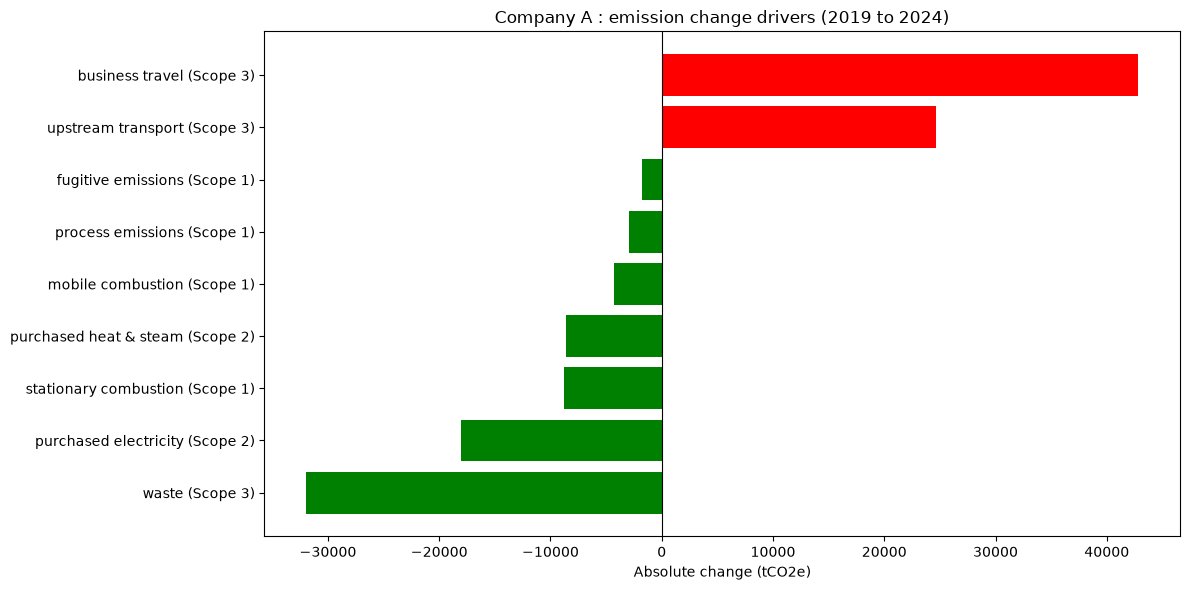

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['red' if x > 0 else 'green' for x in q3_drivers['absolute_change']]
ax.barh(
    q3_drivers['category'] + ' (Scope ' + q3_drivers['scope'].astype(str) + ')',
    q3_drivers['absolute_change'],
    color=colors
)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Company A : emission change drivers (2019 to 2024)')
ax.set_xlabel('Absolute change (tCO2e)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Company A was selected as it shows the highest percentage emissions increase among companies with notable variability over time (+15.8% from 2019 to 2024), depite being SBTi-validated.

### Overall picture

Company A's total emissions increased from ~674k tCO2e in 2019 to ~780k tCO2e in 2024 (+106k tCO2e, +15.8%). This increase is entirely driven by two Scope 3 categories, while all other categories are declining.

### Drivers of increase

**Business travel (Scope 3) — +42,840 tCO2e (+35.3%)**
Business travel nearly doubled between 2020 (where it disappears entirely, likely due to COVID-19 travel restrictions) and 2024. This suggests the company has probably not implemented structural changes to reduce travel dependency.

**Upstream transport (Scope 3) — +24,671 tCO2e (+15.7%)**
As Company A's largest emission category in absolute terms (~182k tCO2e in 2024), its continued growth is concerning. It suggests supply chain expansion or increased logistics activity without corresponding efficiency gains.

### Offsetting reductions

All other categories are declining:
- **Waste (Scope 3)** shows the strongest absolute reduction (-32k tCO2e, -27.1%).
- **Purchased electricity (Scope 2)** is down -26.4%, probably driven by renewable energy procurement.
- **Purchased heat & steam (Scope 2)** down -11.6%.
- **Stationary combustion (Scope 1)** down -21.6%.
- Other Scope 1 categories (mobile combustion, process emissions, fugitive emissions) are all modestly declining.

### Structural observation

Company A is making genuine progress on direct emissions (Scope 1) and energy (Scope 2), with reductions across all these categories. However, these gains are more than offset by growth in two hard-to-control Scope 3 categories: business travel and upstream transport.
This profile is consistent with a company that has focused decarbonisation efforts on what it directly controls (its own operations and energy supply) while not yet addressing the behavioural and supply chain levers needed to reduce Scope 3 emissions.


**Note:** 
`purchased goods & services` are absent for Company A in 2019 and 2020 in the **analytical queries**. Investigation of the data reveals:
- **2019** : genuinely absent from the source data.
- **2020** : present in the raw data but carries a negative emissions value, which was excluded from analysis as it could not be validated without business context (see data quality handling).

`Business travel` appears absent for Company A in 2020 in the analytical queries.
- **2020** : genuinely absent from the source data. Can be explained with COVID-19 travel restrictions leading to near-zero corporate travel activity that year.
These situations limit the comparability of Company A's emissions across years and should be interpreted with caution. In particular, the strong growth in business travel (+35.3%) between 2019 and 2024 is likely amplified by the post-COVID rebound effect rather than reflecting a structural long-term trend.

## Q4 — Progress Against Targets

  company_name target_id  year  expected_emissions_tco2e  \
0    Company A   TGT-001  2024             224458.406250   
1    Company D   TGT-004  2024              21745.199219   
2    Company H   TGT-008  2024              90690.398438   
3    Company E   TGT-005  2024              84975.601562   
4    Company B   TGT-002  2024             296841.812500   
5    Company G   TGT-007  2024             199069.906250   
6    Company F   TGT-006  2024             181549.093750   
7    Company C   TGT-003  2024             318835.500000   

   actual_emissions_tco2e      gap_tco2e  is_on_track  
0           232994.402344    8535.996094        False  
1            20328.400146   -1416.799072         True  
2            88329.399414   -2360.999023         True  
3            77782.399414   -7193.202148         True  
4           286094.201172  -10747.611328         True  
5           182410.801758  -16659.104492         True  
6           162876.498047  -18672.595703         True  
7          

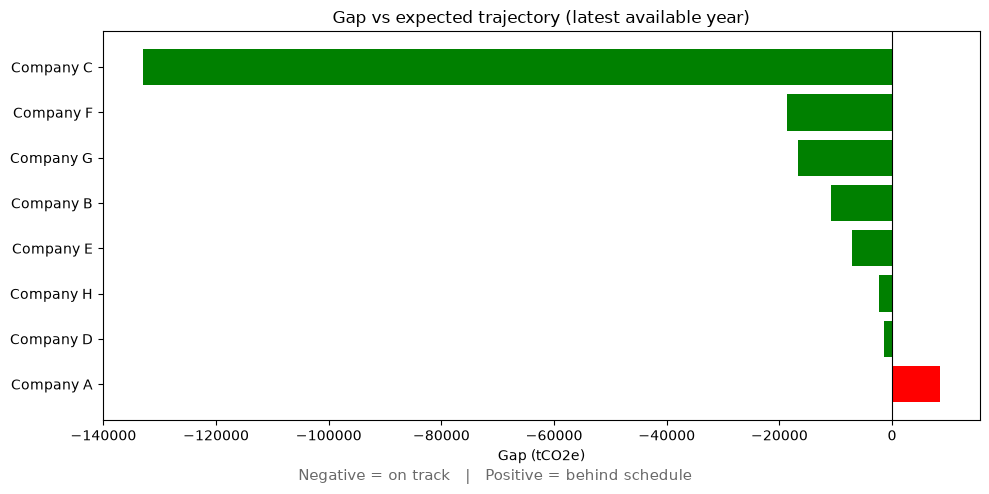

In [10]:
q4 = conn.execute("""
    WITH latest_year AS (
        SELECT
            target_id,
            MAX(year) as latest_year
        FROM fct_company_target_status
        WHERE actual_emissions_tco2e IS NOT NULL
        GROUP BY target_id
    )
    SELECT
        s.target_id,
        s.company_name,
        s.scope_coverage,
        s.sbti_validated,
        s.reduction_pct,
        s.target_year,
        s.year,
        s.expected_emissions_tco2e,
        s.actual_emissions_tco2e,
        s.gap_tco2e,
        s.is_on_track,
        s.total_initiative_reduction
    FROM fct_company_target_status s
    JOIN latest_year l
        ON s.target_id = l.target_id
        AND s.year = l.latest_year
    ORDER BY s.gap_tco2e DESC
""").df()

print(q4[['company_name', 'target_id', 'year', 
           'expected_emissions_tco2e', 'actual_emissions_tco2e', 
           'gap_tco2e', 'is_on_track']])

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['green' if x else 'red' for x in q4['is_on_track']]
ax.barh(q4['company_name'], q4['gap_tco2e'], color=colors)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Gap vs expected trajectory (latest available year)')
ax.set_xlabel('Gap (tCO2e)')

plt.tight_layout()
fig.subplots_adjust(bottom=0.15)
fig.text(0.5, 0.03, 'Negative = on track   |   Positive = behind schedule',
          ha='center', fontsize=11, color='dimgray')
plt.show()

All targets are evaluated at the latest available year (2024) against the provided linear trajectory. Actual emissions are scoped to Scope 1+2 only, matching the `scope_coverage` of all targets in this dataset.

### Results

**7 out of 8 companies are on track** to meet their reduction targets as of 2024.

| Company | Expected (tCO2e) | Actual (tCO2e) | Gap (tCO2e) | On track |
|---|---|---|---|---|
| Company C | 318,836 | 185,801 | -133,034 | ✅ |
| Company F | 181,549 | 162,876 | -18,673 | ✅ |
| Company G | 199,070 | 182,411 | -16,659 | ✅ |
| Company B | 296,842 | 286,094 | -10,748 | ✅ |
| Company E | 84,976 | 77,782 | -7,193 | ✅ |
| Company H | 90,690 | 88,329 | -2,361 | ✅ |
| Company D | 21,745 | 20,328 | -1,417 | ✅ |
| Company A | 224,458 | 232,994 | **+8,536** | ❌ |

### Key observations

**Company C** is by far the strongest performer. Its Scope 1+2 emissions are 133k tCO2e below the expected trajectory, representing a -41.7% gap vs expectation. It is significantly ahead of schedule.

**Company A** is the only company behind schedule, with actual emissions 8,536 tCO2e above the expected trajectory (+3.8%). This is notable because Company A's Scope 1+2 emissions are actually declining in absolute terms. However the **pace 
of reduction** is insufficient to match the linear trajectory committed to in its target. The gap is driven by a slower-than-planned decarbonisation rate.

**Company H and Company D** are on track but with very thin margins (-2361 and -1417 tCO2e respectively), any increase in Scope 1+2 emissions in coming years could put them behind schedule.

### Important caveat

This analysis covers **Scope 1+2 only**, matching the `scope_coverage` of all targets in the dataset. The overall emissions trends observed in Q1 (which include Scope 3) tell a different story: companies like Company B show **overall emissions growth when Scope 3 is included**, despite being **on track for their Scope 1+2 targets**. This highlights a significant limitation of reduction commitments that exclude Scope 3, which represents ~74% of total emissions in this dataset.

   company_name  year  cumulative_actual  cumulative_expected
0     Company A  2019       2.774205e+05         2.774205e+05
1     Company A  2020       5.452350e+05         5.442486e+05
2     Company A  2021       8.078436e+05         8.004843e+05
3     Company A  2022       1.058386e+06         1.046128e+06
4     Company A  2023       1.297399e+06         1.281178e+06
5     Company A  2024       1.530393e+06         1.505637e+06
6     Company B  2019       3.437115e+05         3.437115e+05
7     Company B  2020       6.744248e+05         6.780490e+05
8     Company B  2021       9.926960e+05         1.003013e+06
9     Company B  2022       1.297650e+06         1.318602e+06
10    Company B  2023       1.516707e+06         1.624818e+06
11    Company B  2024       1.802802e+06         1.921660e+06
12    Company C  2019       2.248199e+05         3.597118e+05
13    Company C  2020       4.428049e+05         7.112483e+05
14    Company C  2021       6.209204e+05         1.054610e+06
15    Co

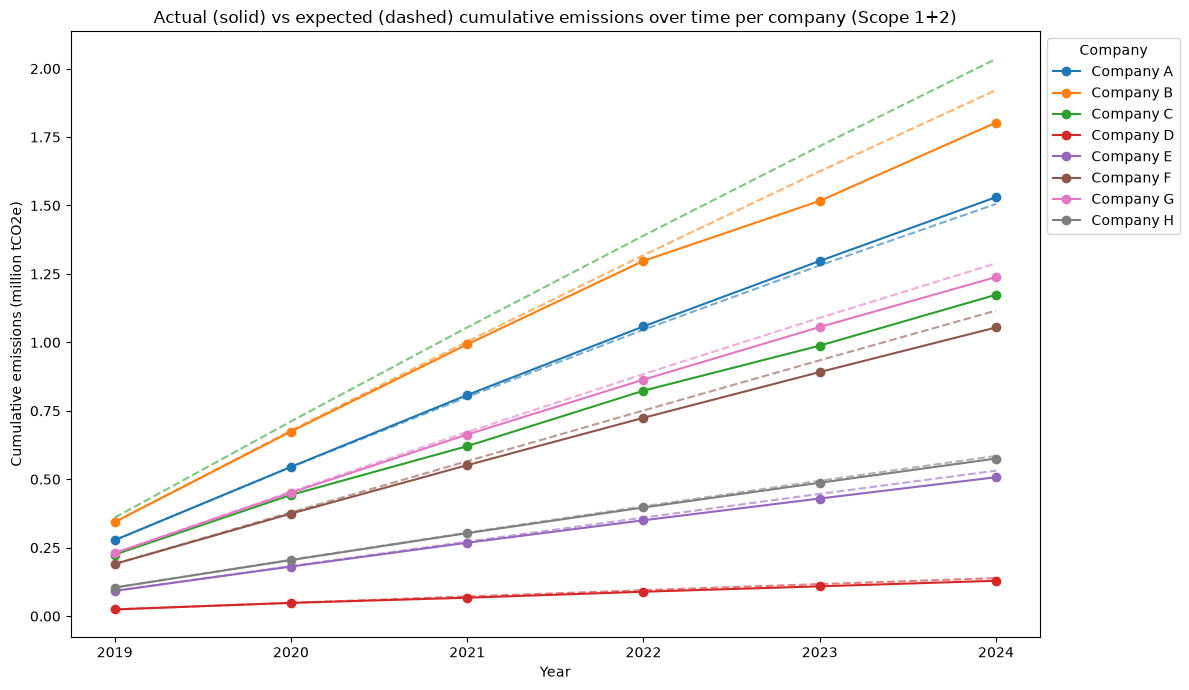

In [11]:
q4_cumulative_time = conn.execute("""
    SELECT
        company_name,
        year,
        SUM(actual_emissions_tco2e) OVER (
            PARTITION BY company_name
            ORDER BY year
        ) AS cumulative_actual,
        SUM(expected_emissions_tco2e) OVER (
            PARTITION BY company_name
            ORDER BY year
        ) AS cumulative_expected
    FROM fct_company_target_status
    WHERE actual_emissions_tco2e IS NOT NULL
    ORDER BY company_name, year
""").df()

print(q4_cumulative_time)

fig, ax = plt.subplots(figsize=(12, 7))

colors = plt.cm.tab10.colors

for i, (company, group) in enumerate(q4_cumulative_time.groupby('company_name')):
    # Cumulative actual — trait plein
    ax.plot(
        group['year'],
        group['cumulative_actual'] / 1000,
        marker='o',
        label=company,
        color=colors[i]
    )
    # Cumulative expected — pointillé, même couleur
    ax.plot(
        group['year'],
        group['cumulative_expected'] / 1000,
        linestyle='--',
        color=colors[i],
        alpha=0.6
    )

ax.set_xlabel('Year')
ax.set_ylabel('Cumulative emissions (million tCO2e)')
ax.set_title('Actual (solid) vs expected (dashed) cumulative emissions over time per company (Scope 1+2)')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1000:.2f}'))
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), title='Company')
plt.tight_layout()
plt.show()

## Bonus. Actual vs expected cumulative emissions (Scope 1+2, 2019 to 2024)

### Why this chart was added

Only progress at a single point in time, that is the latest available year (2024), was required in Q4. While this snapshot is useful, it misses an important dimension: **a company can appear on track in 2024 while having systematically 
overshot its trajectory in prior years**.

This matters because CO2 is a stock pollutant: it accumulates in the atmosphere regardless of when it was emitted. A company that emits 10k tCO2e above its trajectory for 5 years and then catches up in year 6 has still contributed more 
to atmospheric warming than a company that stayed on track throughout. The cumulative gap is therefore a more rigorous measure of actual climate impact than a point-in-time comparison. Also in the context of **SBTi validation**, this initiative requires companies to commit to a linear reduction pathway of approximately 4.2% per year to achieve -42% by 2030. 

This chart makes that dynamic visible: the **gap between solid and dashed lines at any point in time represents the carbon budget surplus or deficit accumulated since baseline**. A widening gap means the company is consistently over or under 
its planned trajectory, not just in one year.

### Key observations

**Company C** (green) shows the strongest cumulative performance. Its solid line is consistently and significantly below the dashed line, widening over time. By 2024, it has accumulated ~0.19M tCO2e less than planned cumulatively. This suggests sustained structural reductions rather than a one-off effect.

**Company B** (orange) and **Company G** (pink) show solid lines consistently below their dashed trajectories. Both are building cumulative carbon budget surplus over time, giving them headroom toward 2030.

**Company A** (blue) is the only company whose solid line crosses **above** its dashed line and continues to diverge. By 2024 it has accumulated more emissions than planned. This is consistent with Q4 findings and confirms that Company A's 
underperformance is not a recent phenomenon but a persistent trend since 2021.

**Company F** (brown) and **Company H** (grey) start close to their trajectories and remain tight throughout. They are on track but with no meaningful buffer. Any acceleration in emissions could put them behind schedule.

**Notes:** Even companies with solid lines below their dashed trajectories are still accumulating significant absolute emissions. The graph shows emissions are growing **more slowly than the planned pace**. True decarbonisation would require the slope of the solid lines to flatten progressively toward zero by 2030.